In [19]:
### import libraries

### handle local data
import earthpy

### handle tabular data
import pandas as pd

### libraries for visualization
import holoviews as hv
import hvplot.pandas
import hvplot

### advanced options on matplotlib/seaborn/pandas plots
import matplotlib.pyplot as plt
### common statistical plots for tabular data
import seaborn as sns
### fit an OLS linear regression
from sklearn.linear_model import LinearRegression

In [20]:
### make url for data
ncei_url = ('https://www.ncei.noaa.gov/access/services/da'
            'ta/v1?dataset=daily-summaries&dataTypes=TOBS&stations'
            '=USC00406403&startDate=1950-01-01&endDate=2024-01-01&units=standard')
ncei_url

'https://www.ncei.noaa.gov/access/services/data/v1?dataset=daily-summaries&dataTypes=TOBS&stations=USC00406403&startDate=1950-01-01&endDate=2024-01-01&units=standard'

In [21]:
### get the data using the url
nashville_climate_df = pd.read_csv(
    ncei_url,

    ### tell python which column to use as the index
    index_col = 'DATE',

    ### tell python to treat DATE as a date
    parse_dates = True, 
    na_values = ['NaN']
)

nashville_climate_df

,STATION,TOBS
DATE,,
1999-10-01,USC00406403,NaN
1999-10-02,USC00406403,NaN
1999-10-03,USC00406403,NaN
1999-10-04,USC00406403,NaN
1999-10-05,USC00406403,NaN
...,...,...
2023-12-28,USC00406403,32.0
2023-12-29,USC00406403,38.0
2023-12-30,USC00406403,38.0


In [22]:
### save the climate data
# nashville_climate_df.to_csv('nashville_climate_df.csv')

In [23]:
### create new dataframe for temp column
nashville_temp_df = nashville_climate_df[['TOBS']]
nashville_temp_df

,TOBS
DATE,
1999-10-01,NaN
1999-10-02,NaN
1999-10-03,NaN
1999-10-04,NaN
1999-10-05,NaN
...,...
2023-12-28,32.0
2023-12-29,38.0
2023-12-30,38.0


In [24]:
### rename columns to include units
nashville_temp_units_df = nashville_temp_df.rename(columns={
    'TOBS': 'temp_f',
})

nashville_temp_units_df

,temp_f
DATE,
1999-10-01,NaN
1999-10-02,NaN
1999-10-03,NaN
1999-10-04,NaN
1999-10-05,NaN
...,...
2023-12-28,32.0
2023-12-29,38.0
2023-12-30,38.0


In [25]:
### convert temp from f to c units using conversion equation
nashville_temp_units_df['temp_c']= (nashville_temp_units_df['temp_f']-32)*5/9
nashville_temp_units_df

,temp_f,temp_c
DATE,,
1999-10-01,NaN,NaN
1999-10-02,NaN,NaN
1999-10-03,NaN,NaN
1999-10-04,NaN,NaN
1999-10-05,NaN,NaN
...,...,...
2023-12-28,32.0,0.000000
2023-12-29,38.0,3.333333
2023-12-30,38.0,3.333333


<Axes: title={'center': 'Daily Temperature in Nashville, TN'}, xlabel='Date', ylabel='Temperature ($^\\circ$C)'>

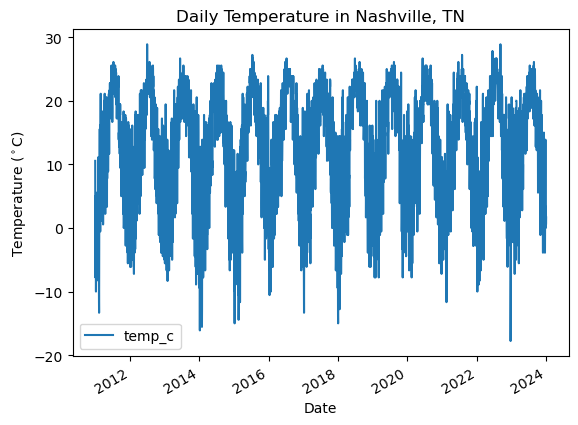

In [26]:
### plot the data using .plot
nashville_temp_units_df.plot(
    y = 'temp_c',
    title = 'Daily Temperature in Nashville, TN',
    xlabel = 'Date',
    ylabel = 'Temperature ($^\circ$C)')

In [27]:
### get mean annual temp
nashville_ann_temp_df = (

    ### resample df
    nashville_temp_units_df

    ### sample annually
    .resample('YS')

    ### calculate mean
    .mean()
)

nashville_ann_temp_df

,temp_f,temp_c
DATE,,
1999-01-01,NaN,NaN
2000-01-01,NaN,NaN
2001-01-01,NaN,NaN
2002-01-01,NaN,NaN
2003-01-01,NaN,NaN
2004-01-01,NaN,NaN
2005-01-01,NaN,NaN
2006-01-01,NaN,NaN
2007-01-01,NaN,NaN


<Axes: title={'center': 'Mean Annual Temperature in Nashville, TN'}, xlabel='Year', ylabel='Temperature ($^\\circ$C)'>

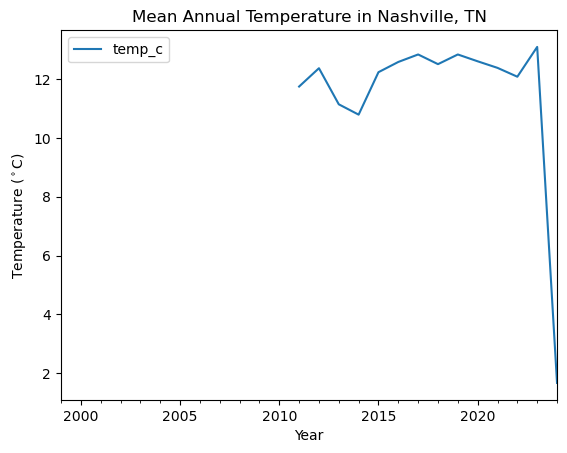

In [28]:
### plot the annual data
nashville_ann_temp_df.plot(
    y = 'temp_c',
    title = 'Mean Annual Temperature in Nashville, TN',
    xlabel = 'Year',
    ylabel = 'Temperature ($^\circ$C)'
)

In [29]:
### subset data to just include c
nashville_ann_temp_c_df = nashville_ann_temp_df[['temp_c']]

### subset data to remove missing data and 2024 outlier
nashville_complete_data_df = nashville_ann_temp_c_df.loc['2010': '2023']

nashville_complete_data_df = nashville_complete_data_df.temp_c.dropna()


In [30]:
nashville_complete_data_df


DATE
2011-01-01    11.749311
2012-01-01    12.372495
2013-01-01    11.144968
2014-01-01    10.792998
2015-01-01    12.237443
2016-01-01    12.585470
2017-01-01    12.840354
2018-01-01    12.510684
2019-01-01    12.840183
2020-01-01    12.607772
2021-01-01    12.384451
2022-01-01    12.083333
2023-01-01    13.096992
Freq: YS-JAN, Name: temp_c, dtype: float64

<Axes: title={'center': 'Mean Annual Temperature in Nashville, TN'}, xlabel='Year', ylabel='Temperature ($^\\circ$C)'>

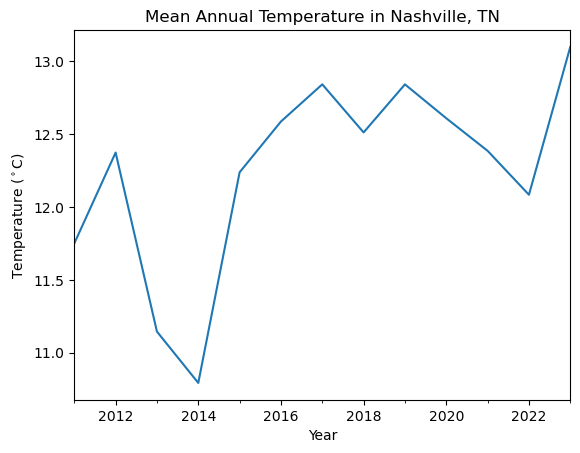

In [31]:
### plot the new subset just to check
nashville_complete_data_df.plot(
    y = 'temp_c',
    title = 'Mean Annual Temperature in Nashville, TN',
    xlabel = 'Year',
    ylabel = 'Temperature ($^\circ$C)'
)

In [32]:
### make an interactive plot

### make the interative plot viewable
hvplot.extension("bokeh")

### plot the annual data interactively
nashville_complete_data_plot= nashville_complete_data_df.hvplot(
    y = 'temp_c',
    title = 'Mean Annual Temperature in Nashville, TN',
    xlabel = 'Year',
    ylabel = 'Temperature (°C)'
)

### view the plot 
nashville_complete_data_plot

:Curve   [DATE]   (temp_c)

In [33]:
### save interactive plot 
hv.save(nashville_complete_data_plot, 'nashville_annual_temp_interactive.html')

In [34]:
### fit an OLS Linear Regression to the data

### define independent variable
### reshape 'year' to be a 2D array for scikit-learn
ind_variable = nashville_complete_data_df.index.year.values.reshape(-1,1)

### define dependent variable
dep_variable = nashville_complete_data_df

### make linear regression model
model = LinearRegression()

### fit the model on the data
model.fit (ind_variable, dep_variable)

### calculate and print metrics
print(f'Slope: {model.coef_[0]} degrees per year')

Slope: 0.09985284687967606 degrees per year


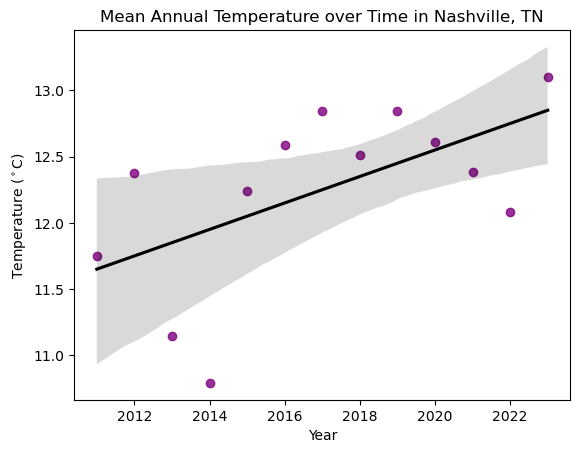

In [36]:
### plot data
ax = sns.regplot(
    x = nashville_complete_data_df.index.year, 
    y = nashville_complete_data_df,

    ### change color of data points 
    color = 'purple',

    ### change color of trend line
    line_kws= {'color': 'black'}

)

### make labels
ax.set(
    title = 'Mean Annual Temperature over Time in Nashville, TN',
    xlabel = 'Year',
    ylabel = 'Temperature ($^\circ$C)'
)

### save trendline plot 
plt.savefig('/workspaces/01-climate-fall-template/nashville_temperature_trend.jpeg')

### plot it
plt.show()
